**DecodeLabs Industrial Training – Project 1**

**Advanced Exploratory Data Analysis & Feature Engineering on an E-Commerce Dataset**

## Project Overview

This project focuses on analyzing an e-commerce order dataset using Python. The objective is to clean and preprocess the data, perform exploratory data analysis (EDA), identify and handle missing values and outliers, engineer meaningful features, and prepare the dataset for future machine learning applications.

## Objectives

- Understand the structure and quality of the dataset.
- Identify and handle missing values.
- Detect and treat outliers.
- Perform exploratory data analysis.
- Engineer meaningful features from existing variables.
- Generate business insights from the data.
- Prepare the dataset for further analysis and machine learning.

**STEP 1 - Importing Required Libraries**

In [199]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

**STEP 2 - Loading the dataset**

In [200]:
df = pd.read_csv("Dataset for Data Analytics - Sheet1.csv")

**STEP 3- Understanding the dataset**

In [201]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [202]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 1200
Number of Columns : 14


In [203]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [205]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,1200.0,2.945833,1.407557,1.00,2.0000,3.000,4.000,5.00
UnitPrice,1200.0,356.412750,197.177146,11.39,186.0625,364.210,521.570,699.93
ItemsInCart,1200.0,5.485000,2.281983,1.00,4.0000,5.000,7.000,10.00
TotalPrice,1200.0,1053.968300,819.856558,11.39,410.5200,823.615,1578.475,3456.40


In [206]:
df.describe(include="object").T

,count,unique,top,freq
OrderID,1200,1200,ORD201183,1
Date,1200,671,2023-08-20,8
CustomerID,1200,1189,C46651,2
Product,1200,7,Printer,181
ShippingAddress,1200,655,533 Main St,8
PaymentMethod,1200,5,Online,258
OrderStatus,1200,5,Cancelled,250
TrackingNumber,1200,1200,TRK83653396,1
CouponCode,891,3,FREESHIP,313
ReferralSource,1200,5,Instagram,259


In [207]:
df.sample(5, random_state=42)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1178,ORD201178,2024-09-08,C65107,Monitor,1,70.24,456 Main St,Credit Card,Cancelled,TRK10261578,4,FREESHIP,Google,70.24
865,ORD200865,2023-04-30,C72241,Monitor,4,677.37,156 Main St,Cash,Pending,TRK76270481,8,SAVE10,Google,2709.48
101,ORD200101,2023-11-25,C15283,Printer,1,381.02,152 Main St,Cash,Shipped,TRK19286291,6,NaN,Google,381.02
439,ORD200439,2024-09-08,C91155,Tablet,1,146.32,321 Main St,Online,Shipped,TRK36260319,4,WINTER15,Facebook,146.32
58,ORD200058,2023-01-15,C60190,Phone,4,474.69,202 Main St,Gift Card,Cancelled,TRK70857868,6,SAVE10,Google,1898.76


**STEP 4 - Data Quality Assessment**

In [208]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [209]:
df.isnull().sum()/len(df)*100

,0
OrderID,0.00
Date,0.00
CustomerID,0.00
Product,0.00
Quantity,0.00
UnitPrice,0.00
ShippingAddress,0.00
PaymentMethod,0.00
OrderStatus,0.00
TrackingNumber,0.00


In [210]:
df.duplicated().sum()

np.int64(0)

**STEP 5 - Data Cleaning**

In [211]:
df["Date"] = pd.to_datetime(df["Date"])

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [213]:
df["CouponCode"].value_counts(dropna=False)

,count
CouponCode,
FREESHIP,313
NaN,309
WINTER15,292
SAVE10,286


In [214]:
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [215]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


**STEP 6 - Outlier Detection and Treatment**

In [216]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_columns

['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

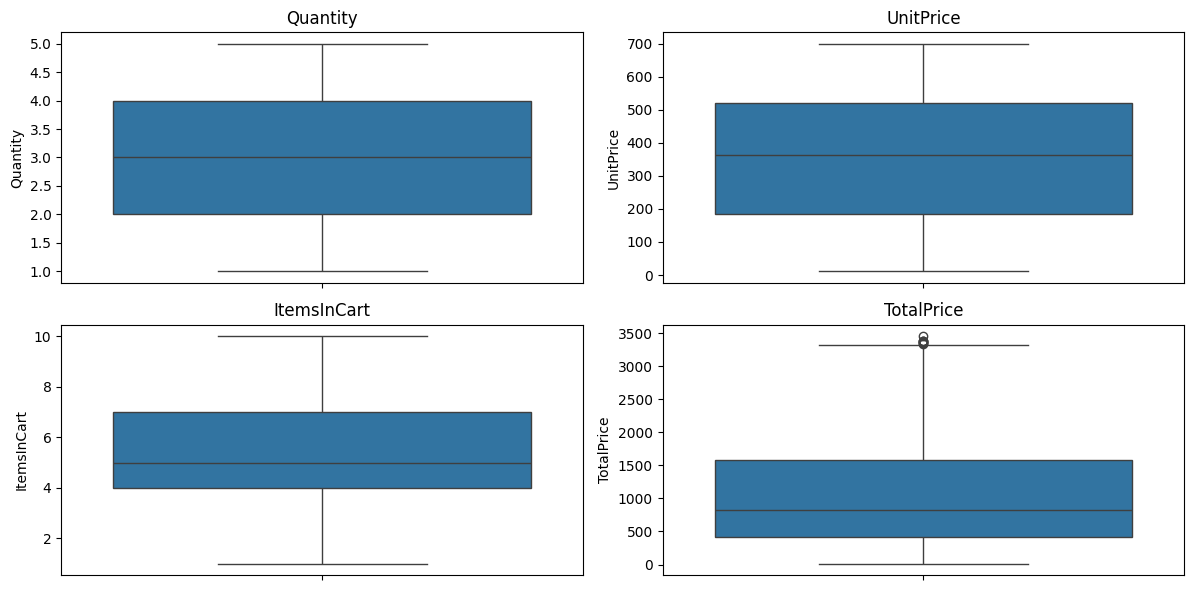

In [217]:
plt.figure(figsize=(12,6))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [218]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [219]:
print(f"Lower Bound : {lower_bound}")
print(f"Upper Bound : {upper_bound}")

Lower Bound : -1341.4125
Upper Bound : 3330.4075


In [220]:
df["TotalPrice"] = df["TotalPrice"].clip(
    lower=lower_bound,
    upper=upper_bound
)

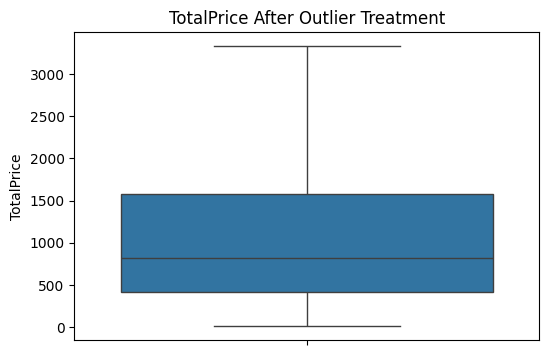

In [221]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["TotalPrice"])
plt.title("TotalPrice After Outlier Treatment")
plt.show()

**STEP 7 — Feature Engineering**

In [222]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

In [223]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,Weekday
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,January,4,Wednesday
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,August,23,Friday
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,February,27,Tuesday
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,October,15,Sunday
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,May,8,Thursday


**STEP 8 - Exploratory Data Analysis**

**8.1 Product Analysis**

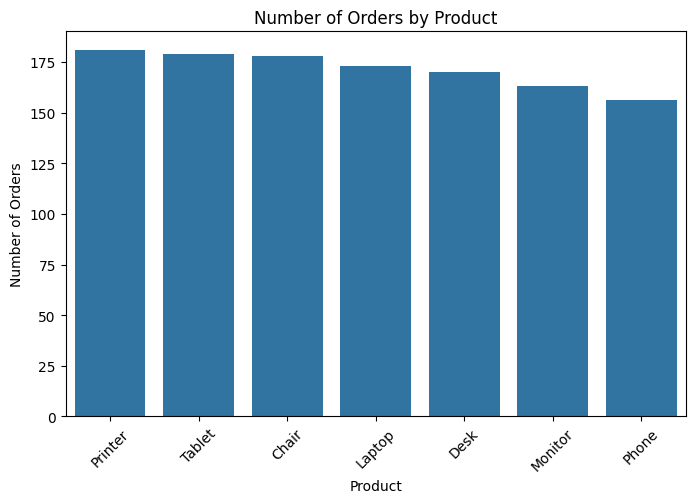

In [224]:
#Which products are ordered the most?

plt.figure(figsize=(8,5))

sns.countplot(x="Product", data=df, order=df["Product"].value_counts().index)

plt.title("Number of Orders by Product")
plt.xlabel("Product")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

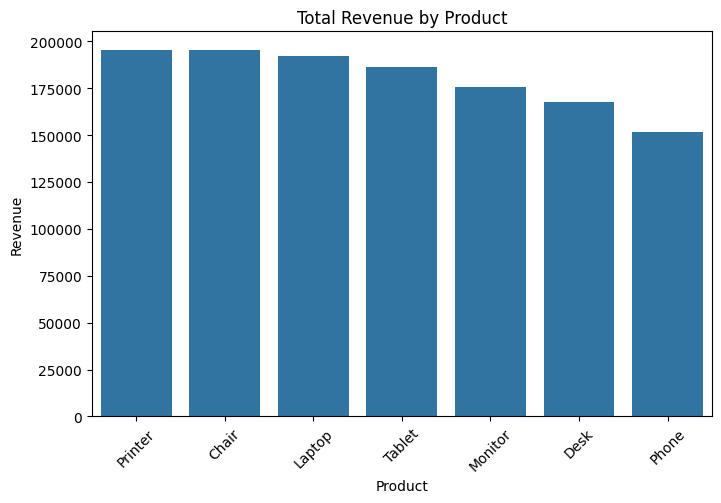

In [225]:
#Which products generate the highest revenue?

product_sales = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(x=product_sales.index, y=product_sales.values)

plt.title("Total Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

**8.2 Payment Analysis**

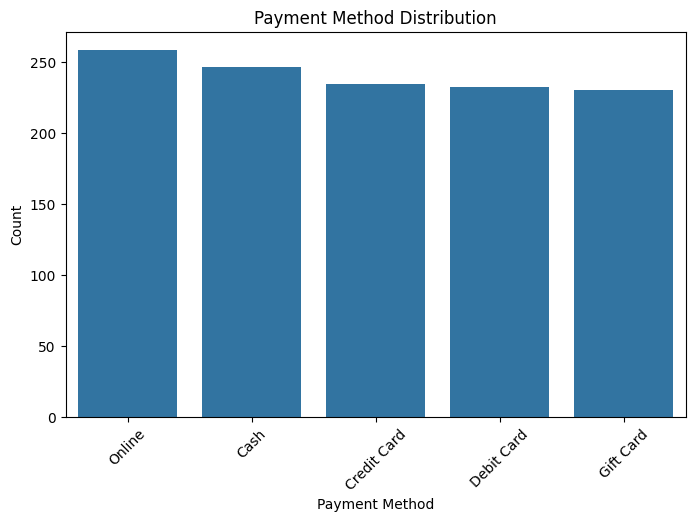

In [226]:
#Which payment method is most preferred?

plt.figure(figsize=(8,5))

sns.countplot(
    x="PaymentMethod",
    data=df,
    order=df["PaymentMethod"].value_counts().index
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

**8.3 Order Status**

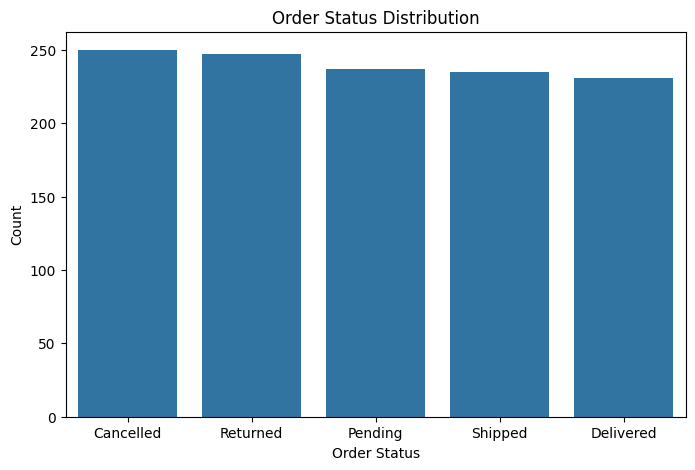

In [227]:
#What is the distribution of order statuses?

plt.figure(figsize=(8,5))

sns.countplot(
    x="OrderStatus",
    data=df,
    order=df["OrderStatus"].value_counts().index
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")

plt.show()

**8.4 Coupon Analysis**

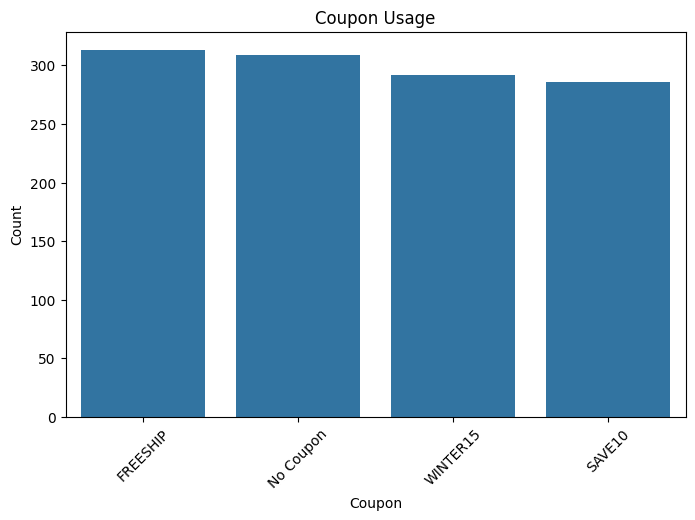

In [228]:
#How many customers used a coupon?

plt.figure(figsize=(8,5))

sns.countplot(
    x="CouponCode",
    data=df,
    order=df["CouponCode"].value_counts().index
)

plt.title("Coupon Usage")
plt.xlabel("Coupon")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

**8.5 Referral Source**

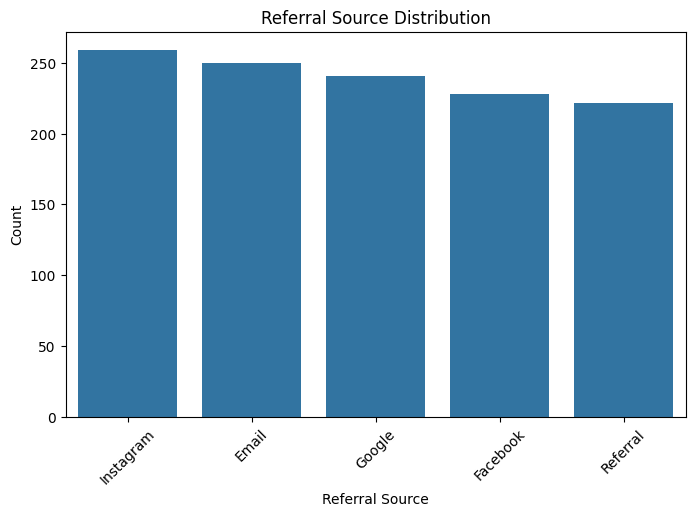

In [229]:
#Which marketing source generated the most orders?

plt.figure(figsize=(8,5))

sns.countplot(
    x="ReferralSource",
    data=df,
    order=df["ReferralSource"].value_counts().index
)

plt.title("Referral Source Distribution")
plt.xlabel("Referral Source")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

**8.6 Time-based Analysis**

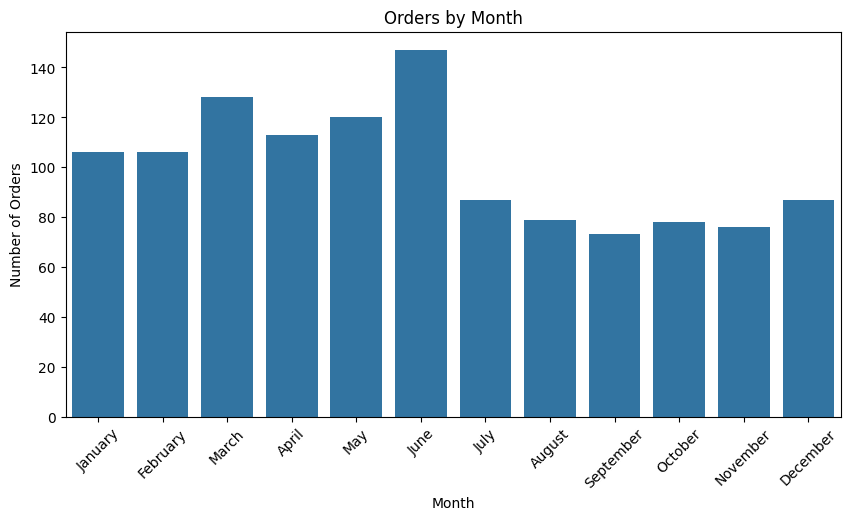

In [230]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_orders = df["Month"].value_counts().reindex(month_order)

plt.figure(figsize=(10,5))

sns.barplot(
    x=monthly_orders.index,
    y=monthly_orders.values
)

plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

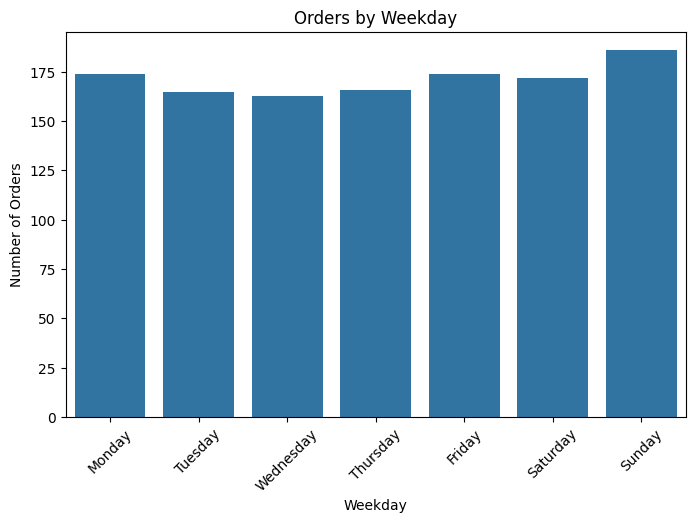

In [231]:
weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

weekday_orders = df["Weekday"].value_counts().reindex(weekday_order)

plt.figure(figsize=(8,5))

sns.barplot(
    x=weekday_orders.index,
    y=weekday_orders.values
)

plt.title("Orders by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

**8.7** **Numerical** **Analysis**

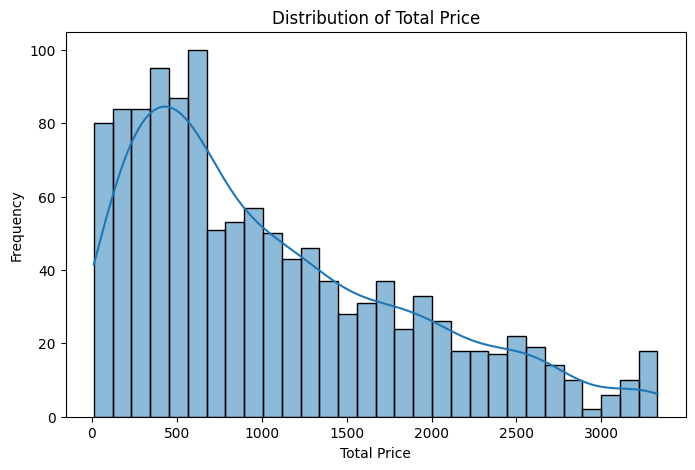

In [232]:
#What is the distribution of TotalPrice?

plt.figure(figsize=(8,5))

sns.histplot(df["TotalPrice"], bins=30, kde=True)

plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")

plt.show()

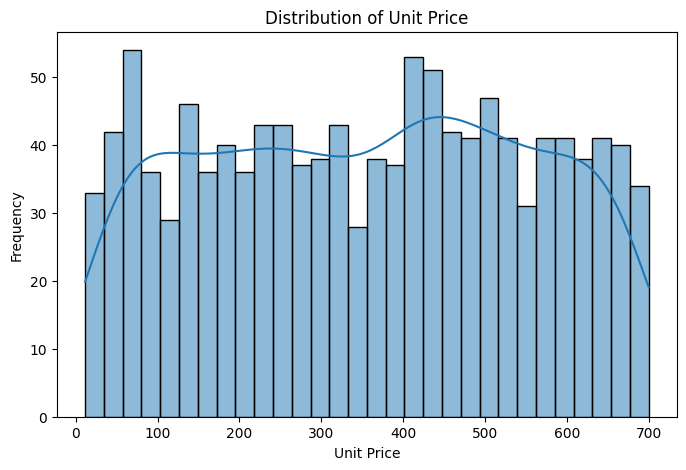

In [233]:
#What is the distribution of UnitPrice?


plt.figure(figsize=(8,5))

sns.histplot(df["UnitPrice"], bins=30, kde=True)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

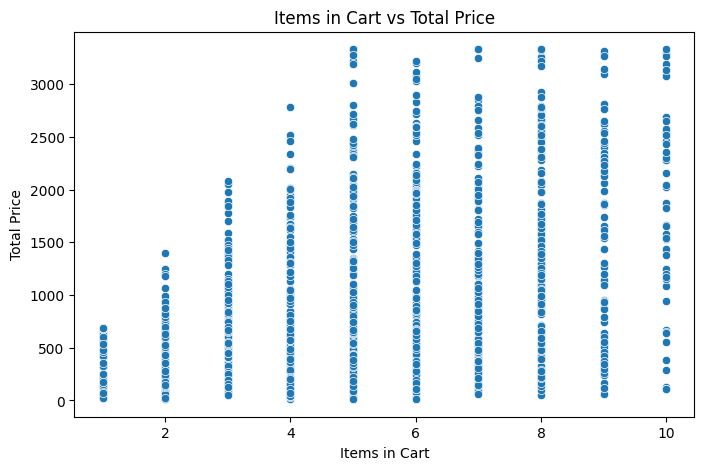

In [234]:
#Does buying more items increase the total price?

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="ItemsInCart",
    y="TotalPrice",
    data=df
)

plt.title("Items in Cart vs Total Price")
plt.xlabel("Items in Cart")
plt.ylabel("Total Price")

plt.show()

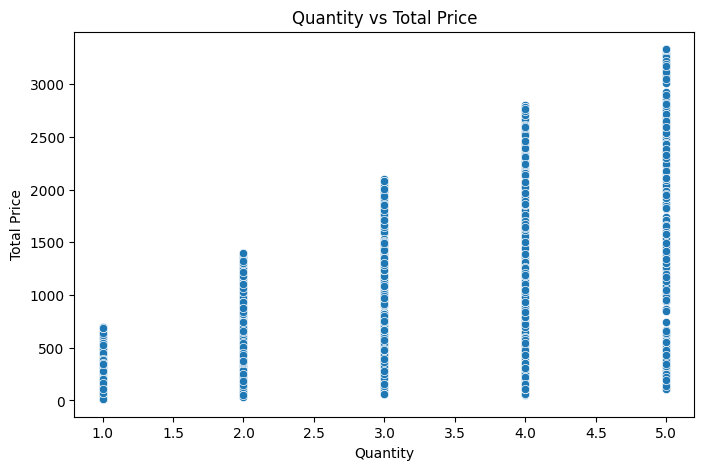

In [235]:
#Does quantity affect total price?

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Quantity",
    y="TotalPrice",
    data=df
)

plt.title("Quantity vs Total Price")
plt.xlabel("Quantity")
plt.ylabel("Total Price")

plt.show()

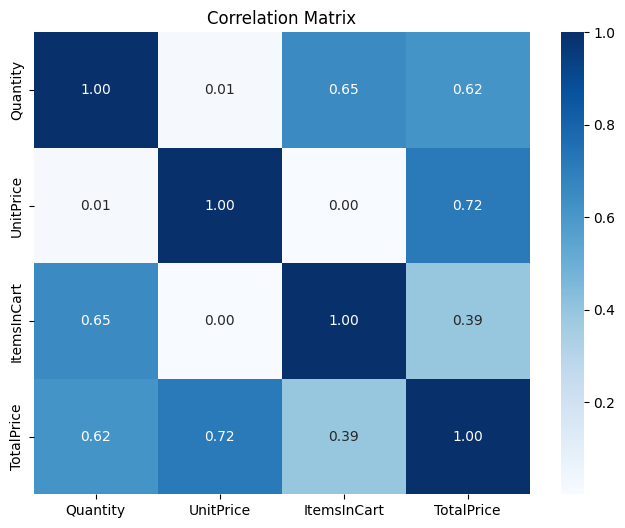

In [236]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# **STEP 9 - Key Insights**

- The dataset contains 1,200 e-commerce orders across multiple product categories.
- Missing values were found only in the `CouponCode` column and were handled by replacing them with "No Coupon".
- Only minor outliers were detected in `TotalPrice`, which were treated using the IQR method.
- Printers generated the highest total revenue, while Phones generated the lowest.
- Online was the most frequently used payment method.
- Instagram was the leading referral source for customer acquisition.
- TotalPrice showed the strongest positive correlation with UnitPrice (0.72), followed by Quantity (0.62).
- Time-based analysis showed that June recorded the highest number of orders, while Sunday had the highest order volume among weekdays.